# Autòmat cel·lular - Natalia Rodriguez i Ashlie Ventura

Aquest notebook estudia un autòmat cel·lular unidimensional a partir d'una regla de Wolfram. Primer es calcula com evoluciona el sistema, després es fa una renormalització per blocs per obtenir el gra guixut i, finalment, es compara la dinàmica original amb la versió agregada per inferir quina regla equivalent la descriu millor.

**Referència:** [Wolfram MathWorld – Elementary Cellular Automaton](https://mathworld.wolfram.com/ElementaryCellularAutomaton.html)

## 1. Coneixements teòrics

Per poder cerar  el nostre propi autòmat cel·lular hem de definir que és, és un sistema unidimensional on cada cel·la pot tenir 2 estats (0 o 1). L'estat de cada cel·la al pas t+1 depèn únicament dels seus 3 veïns (esquerra, centre, dreta) al pas t.

Com que les cel·les dels extrems no tenen tots tres veïns, cal definir una **condició frontera**. En aquest cas s'ha optat per la condició de zeros, això vol dir que les cel·les fora del grid es consideren inactives (valor 0).

A partir d'aquí, el nombre de regles possibles es deriva directament:

- Hi ha $2^3 = 8$ patrons possibles de veïnatge
- Cada patró pot donar 0 o 1 → $2^8 = 256$ regles possibles (de la 0 a la 255)

El número de regla en binari (8 bits) indica directament el resultat per a cada patró:

| Patró | 111 | 110 | 101 | 100 | 011 | 010 | 001 | 000 |
|-------|-----|-----|-----|-----|-----|-----|-----|-----|
| Bit   |  7  |  6  |  5  |  4  |  3  |  2  |  1  |  0  |

### Classes de comportament

Wolfram va estudiar les 256 regles i va observar que, tot i la seva simplicitat, generen comportaments molt diversos. Els va classificar en **4 classes**:

- **Classe I – Comportament uniforme:** el sistema convergeix ràpidament a un estat on totes les cel·les valen el mateix. No hi ha cap estructura interessant. Exemple: Regla 0 (tot negre) o Regla 255 (tot blanc).

- **Classe II – Comportament periòdic:** el sistema genera estructures estables o oscil·lants que es repeteixen en el temps. El patró és regular i predictible. Exemple: Regla 124, que genera un triangle net i ordenat.

- **Classe III – Comportament caòtic:** tot i partir d'una condició inicial molt simple, el sistema genera patrons aparentment aleatoris i imprevisibles. Petits canvis en la condició inicial produeixen resultats completament diferents. Exemple: Regla 30.

- **Classe IV – Comportament complex:** el sistema genera estructures locals que es propaguen i interactuen entre elles de manera sofisticada. És la classe més interessant perquè es troba en el límit entre l'ordre i el caos. L'exemple més conegut és la **Regla 110**, que és **Turing-completa**, és a dir, és capaç de simular qualsevol càlcul computacional.

Aquestes classes són rellevants per entendre els resultats del gra guixut.

## 2. Importació de llibreries

Per començar, importem les llibreries necessàries. S'utilitza numpy per al càlcul matricial i matplotlib per generar totes les visualitzacions directament dins del notebook, de manera que els resultats siguin fàcilment observables sense necessitat d'obrir cap finestra externa.

In [3]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap

%matplotlib inline
plt.rcParams['figure.dpi'] = 120
plt.rcParams['figure.facecolor'] = '#141414'
plt.rcParams['axes.facecolor']   = '#141414'
plt.rcParams['text.color']       = 'white'
plt.rcParams['axes.labelcolor']  = 'white'
plt.rcParams['xtick.color']      = 'white'
plt.rcParams['ytick.color']      = 'white'


## 3. Funcions bàsiques

Les funcions principals que fan funcionar l'autòmat són les següents:

- **get_rule(rule_number)**: converteix el número de regla (0–255) en una llista de 8 bits que el programa utilitza internament per consultar el resultat de cada patró.
- **next_cell(l, c, r, rule)**: calcula el nou estat d'una cel·la a partir dels seus tres veïns (esquerra, centre, dreta) consultant la llista de bits de la regla.
- **evolve(state, rule_bits)**: aplica next_cell a totes les cel·les d'una generació per obtenir la següent, respectant la condició frontera de zeros als extrems.
- **run_ca(rule_number, cols, steps, init)**: orquestra tot el procés. Genera l'estat inicial i crida evolve repetidament per construir l'historial complet de totes les generacions com una matriu de shape.
- **print_rule_table(rule_number)**: mostra per pantalla la taula de transicions d'una regla, indicant quin resultat (0 o 1) produeix cadascun dels 8 patrons de veïnatge possibles.

In [4]:

def get_rule(rule_number):
    """Converteix el número de regla (0-255) en una llista de 8 bits."""
    return [int(x) for x in f"{rule_number:08b}"]


def next_cell(l, c, r, rule):
    """Retorna el valor de la cel·lula al següent pas."""
    return rule[7 - ((l << 2) | (c << 1) | r)]


def evolve(state, rule_bits):
    """Calcula el següent estat del CA (frontera de zeros)."""
    cols = len(state)
    new_state = np.zeros(cols, dtype=int)
    for i in range(cols):
        l = state[i - 1] if i > 0 else 0          # frontera esquerra = 0
        c = state[i]
        r = state[i + 1] if i < cols - 1 else 0   # frontera dreta = 0
        new_state[i] = next_cell(l, c, r, rule_bits)
    return new_state


def run_ca(rule_number, cols=151, steps=75, init='single'):
    """
    Genera l'historial complet d'un CA de Wolfram.

    Args:
        rule_number: Número de regla (0-255)
        cols:        Nombre de cel·les
        steps:       Nombre de generacions
        init:        'single' (1 cel·la central activa) o 'random' (estat aleatori)
    Returns:
        np.ndarray de shape (steps, cols)
    """
    rule_bits = get_rule(rule_number)
    state = np.zeros(cols, dtype=int)
    if init == 'single':
        state[cols // 2] = 1
    else:
        np.random.seed(42)
        state = np.random.randint(0, 2, cols)

    history = [state.copy()]
    for _ in range(steps - 1):
        state = evolve(state, rule_bits)
        history.append(state.copy())
    return np.array(history)


def print_rule_table(rule_number):
    """Mostra la taula de transicions d'una regla de Wolfram."""
    patterns = [(1,1,1),(1,1,0),(1,0,1),(1,0,0),(0,1,1),(0,1,0),(0,0,1),(0,0,0)]
    print(f"Taula de transicions – Regla {rule_number} (binari: {format(rule_number,'08b')})")
    print("  Patró LCR │ Resultat")
    print("  ──────────┼─────────")
    for pat, bit in zip(patterns, format(rule_number,'08b')):
        print(f"    {pat}  │    {bit}")

print_rule_table(110)
print()
print_rule_table(30)

Taula de transicions – Regla 110 (binari: 01101110)
  Patró LCR │ Resultat
  ──────────┼─────────
    (1, 1, 1)  │    0
    (1, 1, 0)  │    1
    (1, 0, 1)  │    1
    (1, 0, 0)  │    0
    (0, 1, 1)  │    1
    (0, 1, 0)  │    1
    (0, 0, 1)  │    1
    (0, 0, 0)  │    0

Taula de transicions – Regla 30 (binari: 00011110)
  Patró LCR │ Resultat
  ──────────┼─────────
    (1, 1, 1)  │    0
    (1, 1, 0)  │    0
    (1, 0, 1)  │    0
    (1, 0, 0)  │    1
    (0, 1, 1)  │    1
    (0, 1, 0)  │    1
    (0, 0, 1)  │    1
    (0, 0, 0)  │    0


Les taules mostren, per a cada regla, quin serà l'estat de la cel·la central al pas següent en funció dels 8 patrons de veïnatge possibles (esquerra, centre, dreta). Per exemple, a la Regla 110, una cel·la amb veïns `(0, 1, 0)` donarà 1, mentre que una amb veïns `(1, 1, 1)` donarà 0. A la Regla 30 s'observa que els patrons amb tots els veïns actius `(1, 1, 1)` o inactius `(0, 0, 0)` produeixen sempre 0, mentre que els patrons mixtos tendeixen a produir 1, cosa que genera el comportament caòtic característic d'aquesta regla. Llegint els resultats de dalt a baix i interpretant-los com un número binari s'obté precisament el número de regla: `01101110` per a la 110 i `00011110` per a la 30.

## 4. Gra guixut K=2

Un cop tenim l'autòmat funcionant, el que fem és aplicar el gra guixut K=2. La idea és reduir la resolució del sistema agrupant les cel·les de 2 en 2 i decidir l'estat de cada bloc per majoria. A partir d'aquest historial reduït, la funció també intenta inferir quina regla de Wolfram descriu millor el comportament agregat, comparant les transicions observades amb les 256 regles possibles i quedant-se amb la que encerta més vegades. Al final retorna la precisió d'aquesta inferència, que ens dirà fins a quin punt el gra guixut es comporta com un autòmat original.

In [5]:
# ── Gra guixut K=2 ──────────────────────────────────────────────────────────

def gra_guixut(history, K=2):
    """
    Renormalitza l'historial agrupant K cel·lules per bloc (vot de majoria).
    Retorna: (historial renormalitzat np.ndarray, regla inferida int, precisió float)
    """
    cg_list = []
    for state in history:
        n_blocs  = len(state) // K
        blocs    = state[:n_blocs * K].reshape(n_blocs, K)
        cg_state = (blocs.sum(axis=1) > K / 2).astype(int)
        cg_list.append(cg_state)
    cg_history = np.array(cg_list)

    # Inferència de la regla a partir de les transicions observades
    pats    = ['111','110','101','100','011','010','001','000']
    comptes = {p: {0: 0, 1: 0} for p in pats}
    n_blocs = cg_history.shape[1]

    for g in range(len(cg_history) - 1):
        for i in range(n_blocs):
            l = cg_history[g, (i - 1) % n_blocs]
            c = cg_history[g, i]
            r = cg_history[g, (i + 1) % n_blocs]
            key = f"{l}{c}{r}"
            comptes[key][int(cg_history[g + 1, i])] += 1

    inferida  = {p: (1 if comptes[p][1] >= comptes[p][0] else 0) for p in pats}
    regla_inf = sum(inferida[p] << (7 - i) for i, p in enumerate(pats))

    total    = sum(comptes[p][0] + comptes[p][1] for p in pats)
    encerts  = sum(comptes[p][inferida[p]] for p in pats)
    precisio = encerts / total * 100 if total else 0.0

    return cg_history, regla_inf, precisio

## 5. Funcions de visualització

Aquestes funcions s'encarreguen de generar les figures directament dins del notebook. *plot_single_rule* mostra tres panells: el CA original, el gra guixut K=2 i les diferències entre tots dos. *plot_combination* mostra quatre panells per comparar dues regles, la seva combinació i el gra guixut resultant.

In [6]:
def plot_single_rule(rule_number, cols=150, steps=75):
    """
    Mostra 3 panells inline:
      1. CA original
      2. Gra guixut K=2
      3. Diferències
    """
    history = run_ca(rule_number, cols=cols, steps=steps)
    cg_history, regla_inf, precisio = gra_guixut(history, K=2)
    cg_cols = cg_history.shape[1]

    orig_sampled = history[:, :cg_cols * 2:2][:, :cg_cols]
    diff_matrix  = (orig_sampled != cg_history).astype(float)

    cmap_orig = ListedColormap(['#141414', 'white'])
    cmap_cg   = ListedColormap(['#141414', '#64C8FF'])
    cmap_diff = ListedColormap(['#141414', '#FF5050'])

    fig, axes = plt.subplots(1, 3, figsize=(16, 6), gridspec_kw={'wspace': 0.08})
    fig.patch.set_facecolor('#141414')

    ax1, ax2, ax3 = axes

    ax1.imshow(history, cmap=cmap_orig, interpolation='nearest', aspect='auto')
    ax1.set_title(f'CA original – Regla {rule_number}', color='white', fontsize=12, pad=8)
    ax1.set_xlabel('Cel·la', color='white')
    ax1.set_ylabel('Generació', color='white')

    ax2.imshow(cg_history, cmap=cmap_cg, interpolation='nearest', aspect='auto')
    ax2.set_title(f'Gra guixut K=2\n→ Regla inferida: {regla_inf}  ({precisio:.0f}% precisió)',
                  color='#64C8FF', fontsize=12, pad=8)
    ax2.set_xlabel('Bloc', color='white')

    ax3.imshow(diff_matrix, cmap=cmap_diff, interpolation='nearest', aspect='auto')
    pct_diff = diff_matrix.mean() * 100
    ax3.set_title(f'Diferències\n({pct_diff:.1f}% de cel·les difereixen)',
                  color='#FF5050', fontsize=12, pad=8)
    ax3.set_xlabel('Bloc', color='white')

    for ax in axes:
        ax.tick_params(colors='white')
        for spine in ax.spines.values():
            spine.set_edgecolor('#444444')

    plt.suptitle(f'Autòmat cel·lular de Wolfram – Regla {rule_number}',
                 color='white', fontsize=14, fontweight='bold', y=1.02)
    plt.tight_layout()
    plt.show()
    print(f"Regla original: {rule_number}  |  Regla inferida: {regla_inf}  "
          f"|  Precisió: {precisio:.1f}%  |  Diferències: {pct_diff:.1f}%")


def plot_combination(rule1, rule2, cols=150, steps=75):
    """
    Mostra 4 panells inline per a la combinació de dues regles.
    """
    rule1_bits = get_rule(rule1)
    rule2_bits = get_rule(rule2)

    s1 = np.zeros(cols, dtype=int);  s1[cols // 2] = 1
    s2 = np.zeros(cols, dtype=int);  s2[cols // 2] = 1

    h1, h2, hc = [s1.copy()], [s2.copy()], [np.maximum(s1, s2).copy()]

    for _ in range(steps - 1):
        s1 = evolve(s1, rule1_bits)
        s2 = evolve(s2, rule2_bits)
        h1.append(s1.copy())
        h2.append(s2.copy())
        hc.append(np.maximum(s1, s2).copy())

    h1 = np.array(h1);  h2 = np.array(h2);  hc = np.array(hc)
    cg_history, regla_inf, precisio = gra_guixut(hc, K=2)

    cmaps = [
        ListedColormap(['#141414', '#FF5050']),
        ListedColormap(['#141414', '#5050FF']),
        ListedColormap(['#141414', '#C800FF']),
        ListedColormap(['#141414', '#50DC78']),
    ]
    titles = [
        f'Regla {rule1}',
        f'Regla {rule2}',
        'Combinació\n(màxim element a element)',
        f'Gra guixut K=2\n→ Regla inferida: {regla_inf}  ({precisio:.0f}%)',
    ]
    colors_title = ['#FF5050', '#8888FF', '#CC44FF', '#50DC78']
    grids = [h1, h2, hc, cg_history]

    fig, axes = plt.subplots(1, 4, figsize=(20, 6), gridspec_kw={'wspace': 0.08})
    fig.patch.set_facecolor('#141414')

    for ax, grid, cmap, title, tc in zip(axes, grids, cmaps, titles, colors_title):
        ax.imshow(grid, cmap=cmap, interpolation='nearest', aspect='auto')
        ax.set_title(title, color=tc, fontsize=11, pad=8)
        ax.set_xlabel('Cel·la / Bloc', color='white')
        ax.tick_params(colors='white')
        for spine in ax.spines.values():
            spine.set_edgecolor('#444444')

    axes[0].set_ylabel('Generació', color='white')
    plt.suptitle(f'Combinació de Regla {rule1} + Regla {rule2} – Gra guixut K=2',
                 color='white', fontsize=14, fontweight='bold', y=1.02)
    plt.tight_layout()
    plt.show()
    print(f"Regles: {rule1} + {rule2}  |  Regla inferida: {regla_inf}  |  Precisió: {precisio:.1f}%")

## 6. Execució: regla individual

En aquest punt ja tenim l'autòmat cel·lular funcionant amb la condició frontera de zeros i el gra guixut K=2. Per observar l'efecte de l'agregació, compararem el comportament dels dos autòmats amb les regles 124, 30 i 110 (regles de diferents classes totes 3), i analitzarem les diferències que apareixen entre l'original i la versió reduïda.

C:\Users\ashve\AppData\Local\Temp\ipykernel_35996\476336751.py:47: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


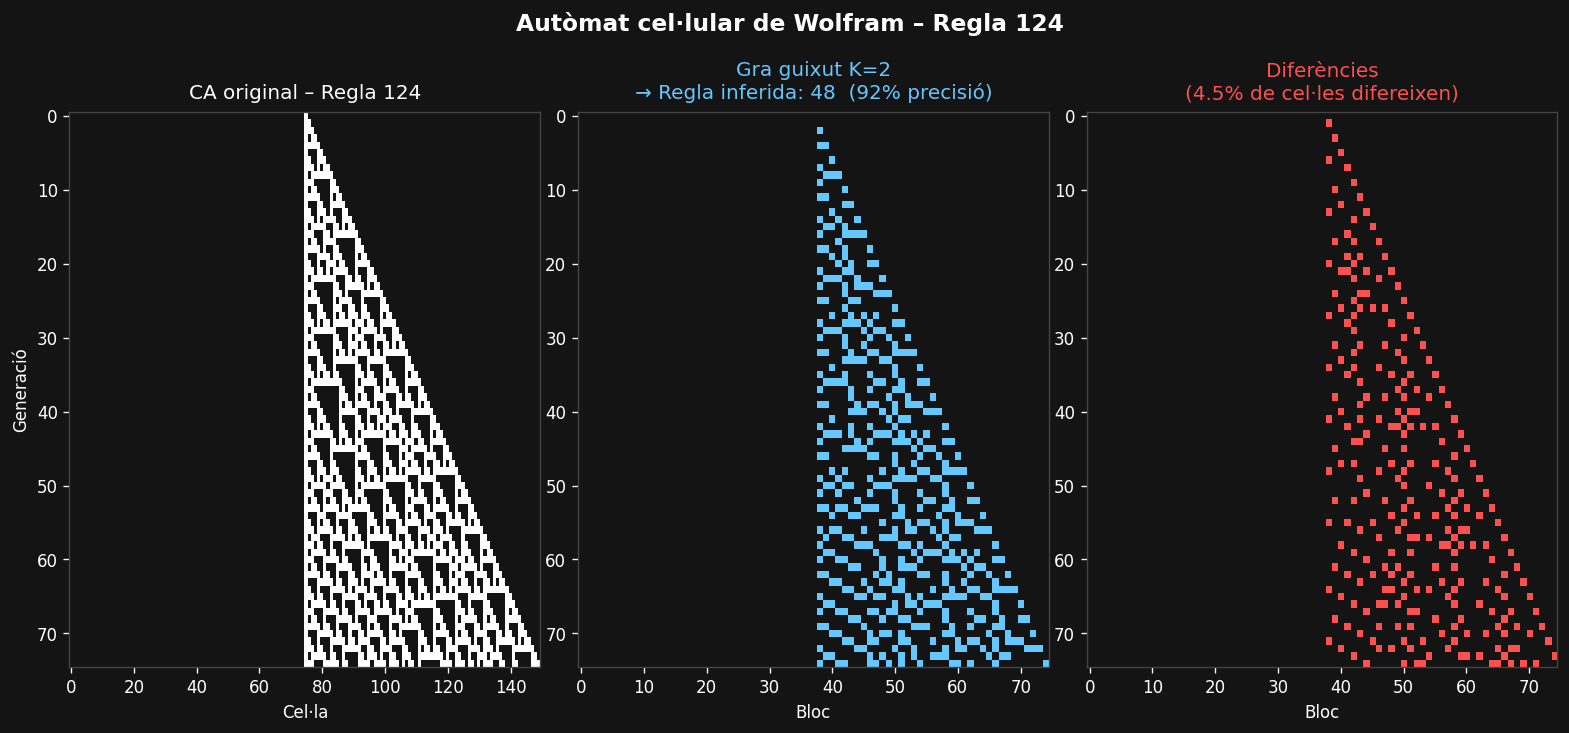

Regla original: 124  |  Regla inferida: 48  |  Precisió: 92.2%  |  Diferències: 4.5%


In [7]:
plot_single_rule(rule_number=124)

La **Regla 124** és una regla de Classe II (comportament regular): l'original mostra un patró triangular clar, i el gra guixut el reprodueix molt bé. La regla inferida és la 48 amb un 92% de precisió i només un 4.5% de cel·les difereixen, cosa que indica que l'agregació per blocs no perd gaire informació quan el comportament és simple i predictible.

C:\Users\ashve\AppData\Local\Temp\ipykernel_35996\476336751.py:47: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


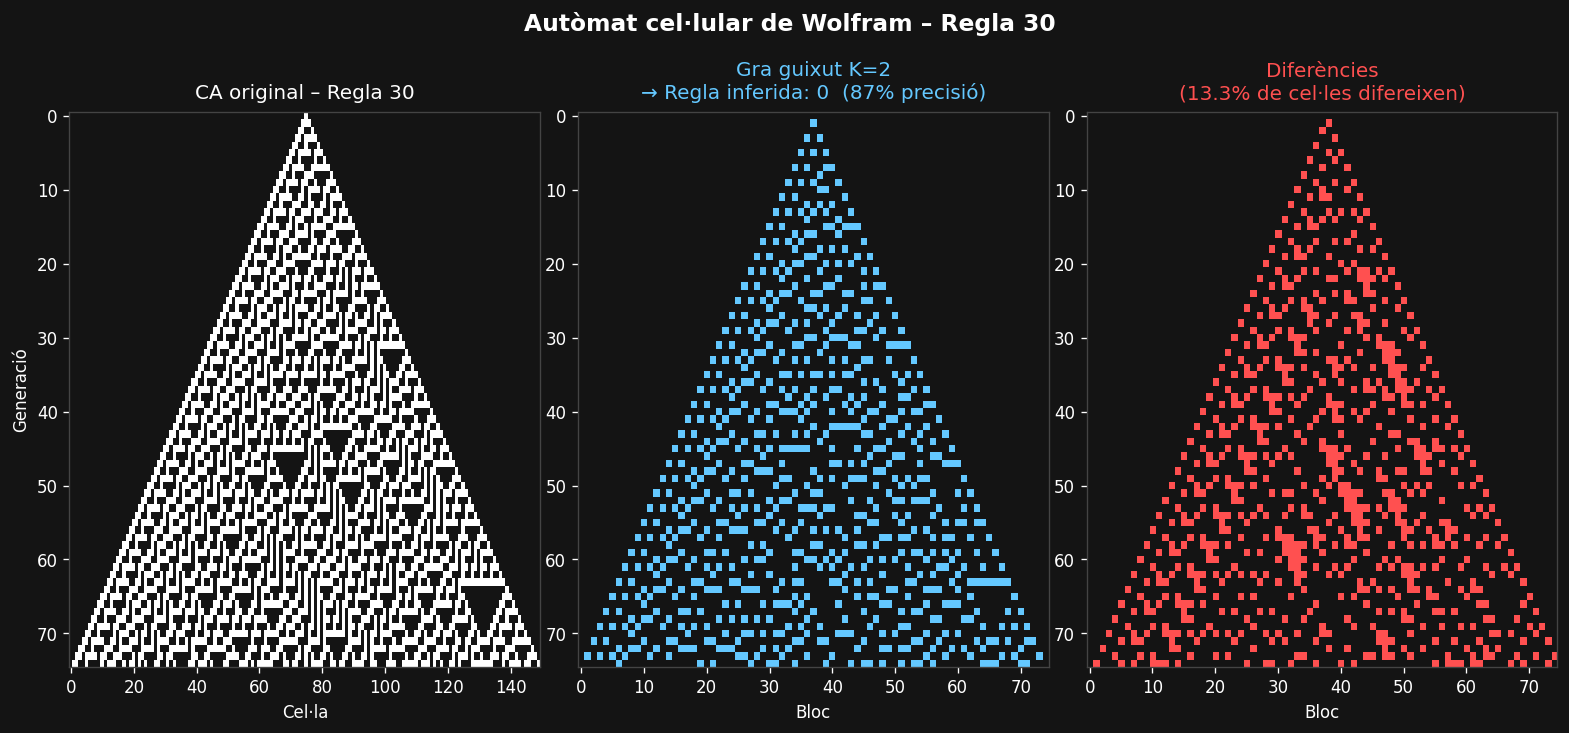

Regla original: 30  |  Regla inferida: 0  |  Precisió: 86.5%  |  Diferències: 13.3%


In [8]:
plot_single_rule(rule_number=30)

La **Regla 30** és un exemple clàssic de **Classe III** (comportament caòtic): es genera un patró aparentment aleatori . El gra guixut aquí perd molt més informació (13.3% de diferències) i la regla inferida és la 0. Això passa perquè el caos de la regla 30 és tan sensible als detalls de cada cel·la que l'agregació per majoria destrueix precisament la informació que el feia interessant.

C:\Users\ashve\AppData\Local\Temp\ipykernel_35996\476336751.py:47: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


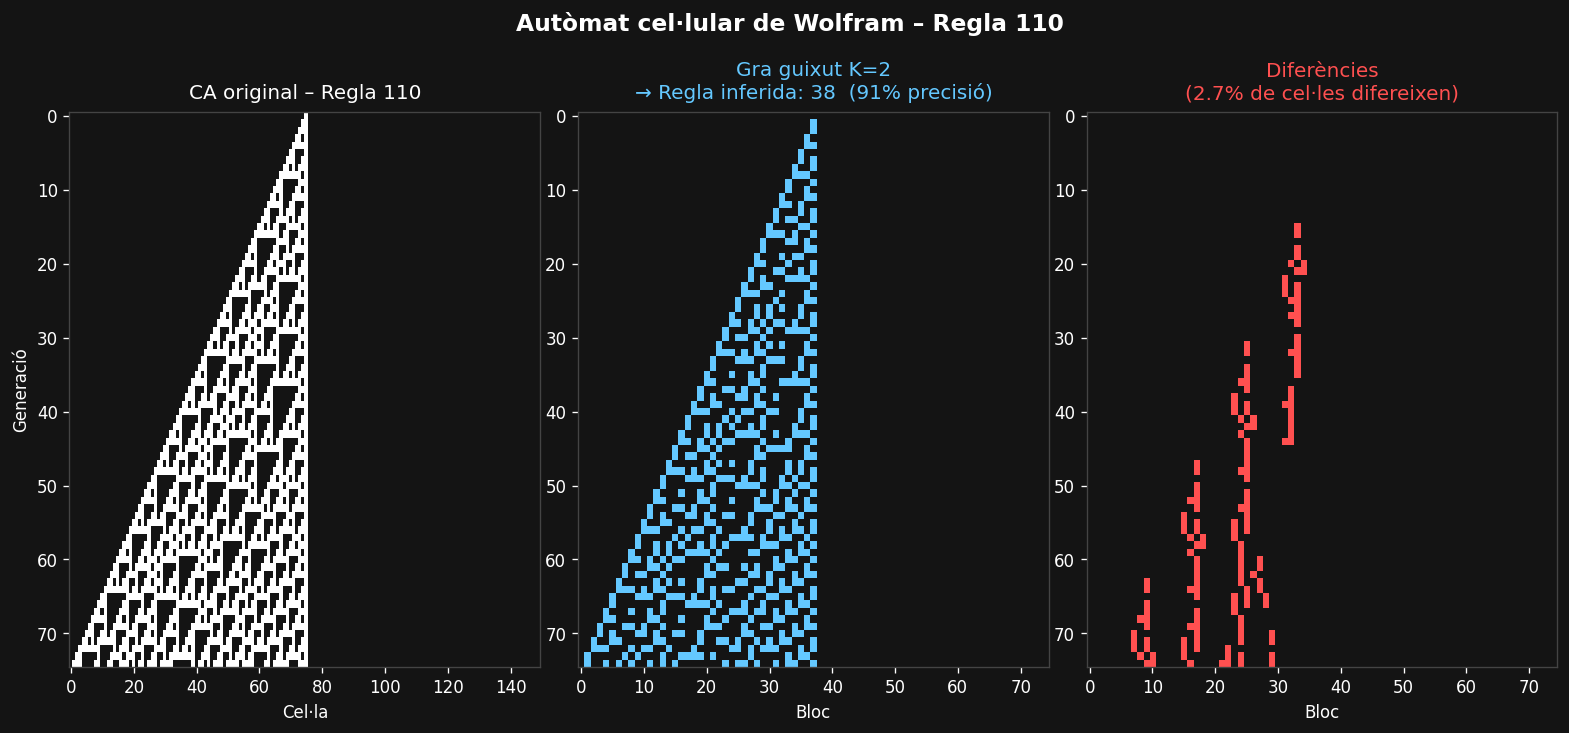

Regla original: 110  |  Regla inferida: 38  |  Precisió: 91.2%  |  Diferències: 2.7%


In [9]:
plot_single_rule(rule_number=110)

La **Regla 110** és de **Classe IV** i és **Turing-completa**. El seu patró original mostra estructures locals complexes que es propaguen i interactuen. El gra guixut aquí funciona sorprenentment bé: només un 2.7% de diferències i un 91% de precisió. Les diferències apareixen concentrades als marges del triangle.

## 7. Execució: combinació de dues regles

A continuació combinem dues regles per màxim element a element i observem com el gra guixut captura el comportament resultant.

C:\Users\ashve\AppData\Local\Temp\ipykernel_35996\476336751.py:104: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


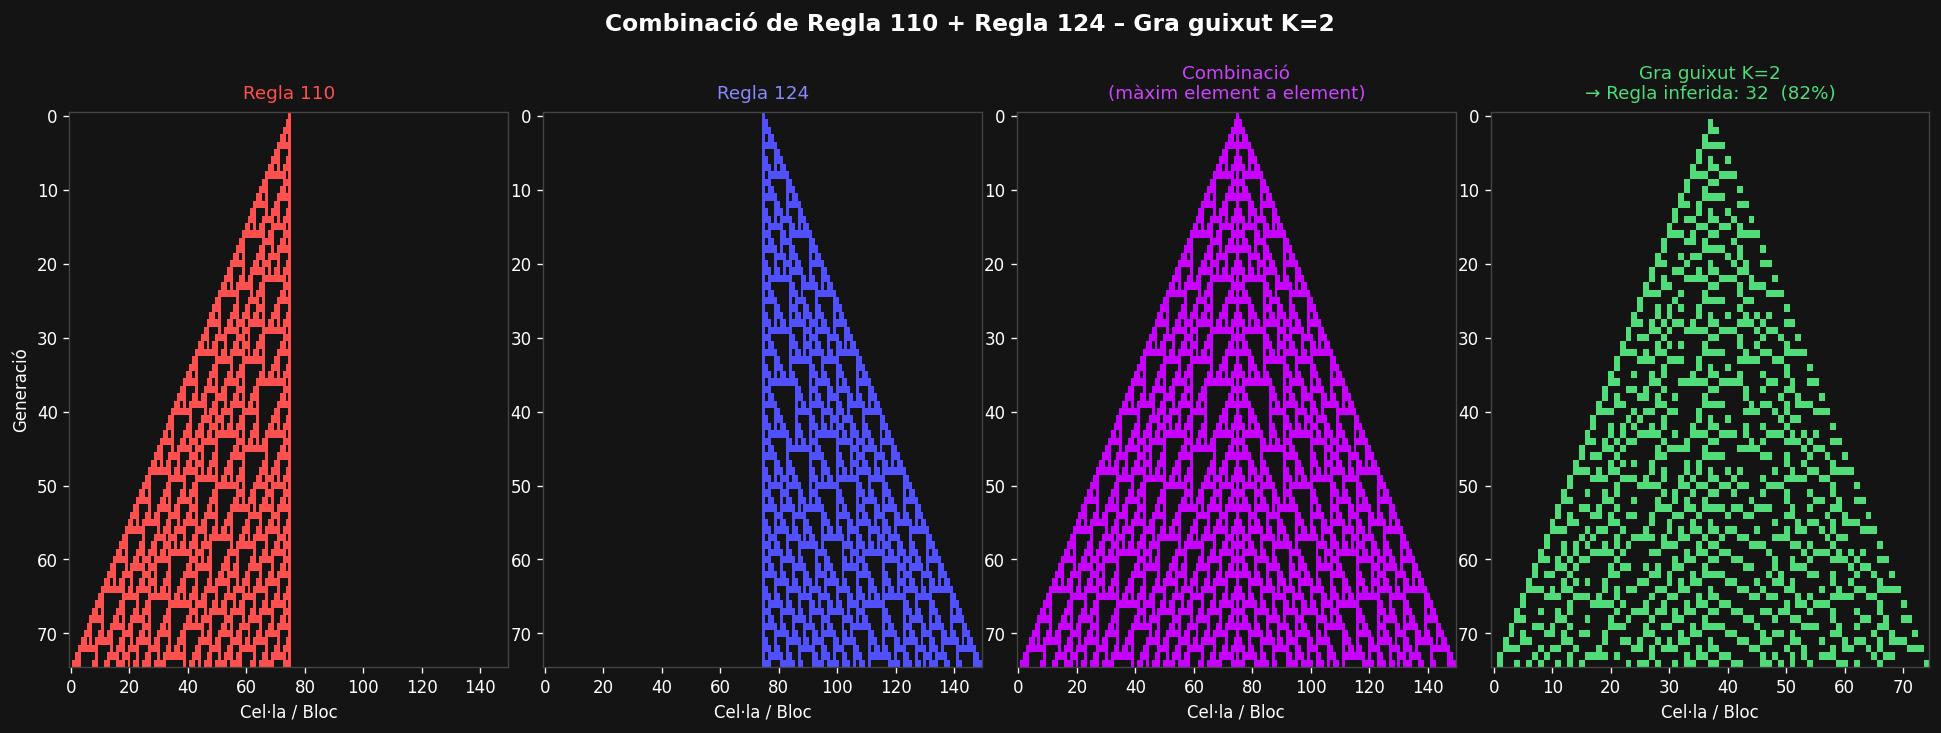

Regles: 110 + 124  |  Regla inferida: 32  |  Precisió: 82.3%


In [10]:
plot_combination(rule1=110, rule2=124)

En la combinació de la **Regla 110 + Regla 124**, les dues regles tenen comportaments compatibles i la combinació genera un patró triangular dens que conserva elements d'ambdues. El gra guixut infereix la regla 32 amb un 82% de precisió i el resultat agregat conserva una estructura reconeixible, cosa que indica que quan es combinen dues regles de comportament similar el gra guixut és capaç de capturar millor la dinàmica resultant.

C:\Users\ashve\AppData\Local\Temp\ipykernel_35996\476336751.py:104: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


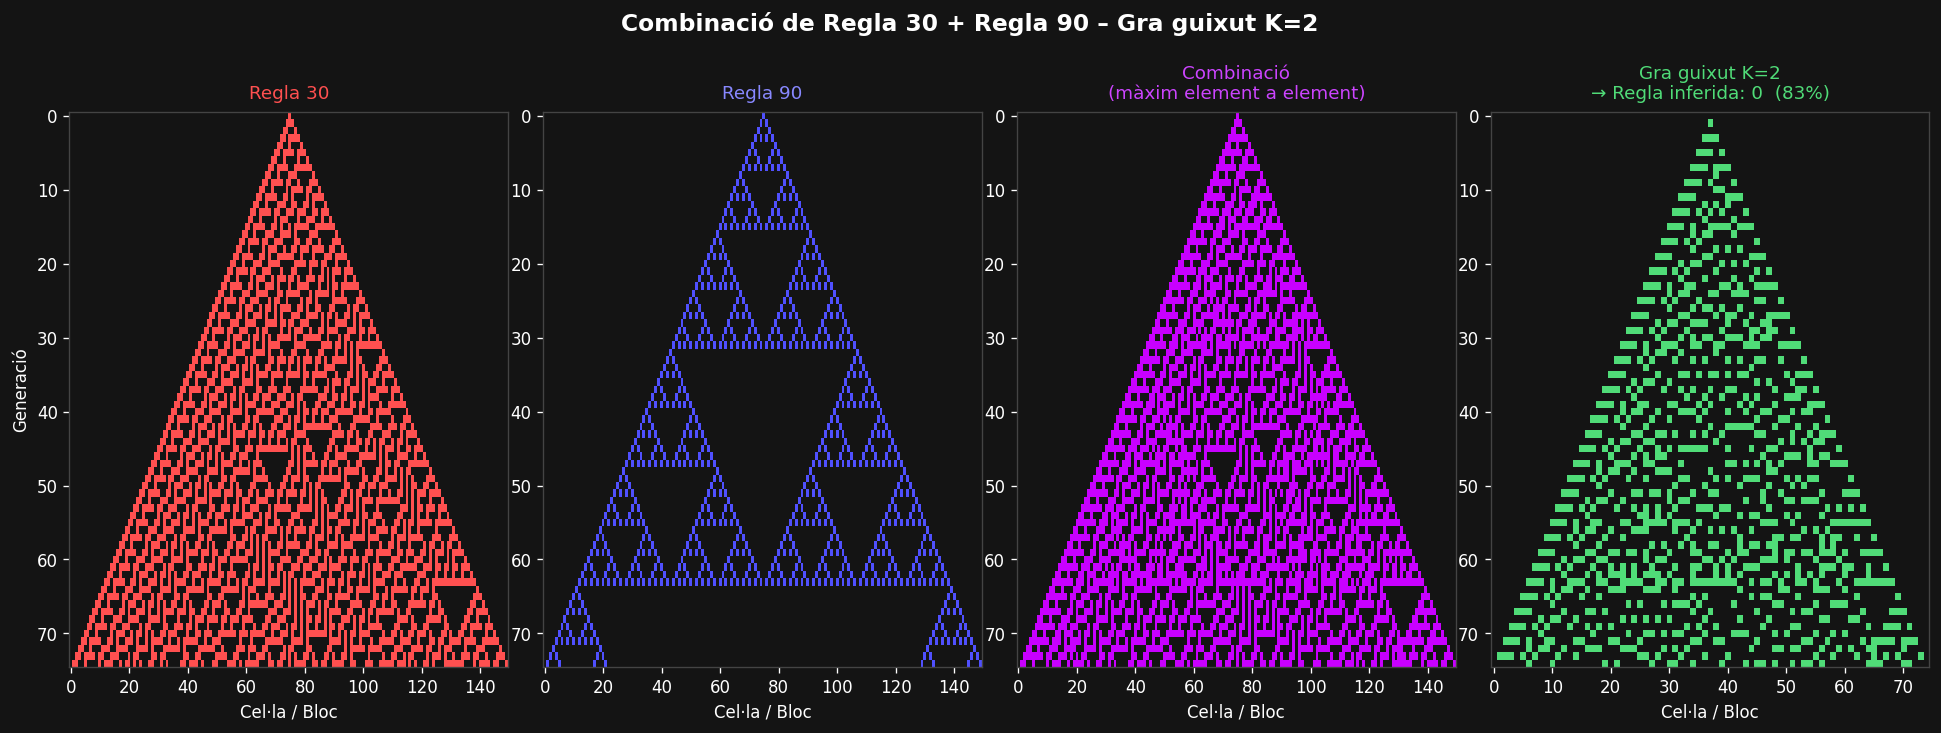

Regles: 30 + 90  |  Regla inferida: 0  |  Precisió: 83.5%


In [11]:
plot_combination(rule1=30, rule2=90)

En la combinació de la **Regla 30 + Regla 90**, el comportament de la 90 (que genera un fractal tipus triangle de Sierpiński molt regular) queda completament submergit pel caos de la 30. La combinació per màxim resulta en un patró que visualment s'assembla molt a la 30 sola, i el gra guixut infereix la regla 0 amb un 83% de precisió, cosa que confirma que el caos domina i l'agregació perd la major part de l'estructura.

## 8. Conclusions

Un cop analitzats els resultats, podem veure que el gra guixut K=2 no funciona igual de bé per a totes les regles de Wolfram. En el cas de la Regla 124, que té un comportament regular, l'agregació captura molt bé la dinàmica original i la regla inferida té una precisió superior al 90%. Això té sentit perquè quan el comportament és simple i ordenat, agrupant les cel·les de 2 en 2 no es perd gaire informació rellevant.

En canvi, amb la Regla 30 el resultat és molt diferent. El seu comportament caòtic fa que petits detalls a nivell de cel·la individual tinguin un impacte gran en l'evolució del sistema, i quan s'agreguen per majoria aquests detalls desapareixen. El resultat és que el gra guixut perd l'estructura caòtica i la regla inferida no s'assembla gens a l'original.

La Regla 110 és el cas més interessant. Tot i ser Turing-completa i tenir un comportament complex, el gra guixut la captura sorprenentment bé, amb menys d'un 3% de diferències. Això suggereix que les estructures que genera la Regla 110 tenen una certa coherència a gran escala que sobreviu a l'agregació.

Pel que fa a les combinacions, hem vist que quan es barregen una regla caòtica i una de regular, el caos domina i el gra guixut perd l'estructura de la regla ordenada. En canvi, quan les dues regles tenen comportaments compatibles, la combinació genera un patró que el gra guixut pot aproximar raonablement bé.

En resum, el gra guixut és una eina útil per estudiar la dinàmica dels autòmats cel·lulars a gran escala, però la seva eficàcia depèn molt del tipus de comportament de la regla original. Com més caòtic és el sistema, més informació es perd en l'agregació i menys representativa és la regla inferida.